In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [3]:
# Load data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))
OE_detailed = OE_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [ ]:
# Count percentage of number of tasks in each AssignmentID == 1
assignment_counts = OE_detailed['AssignmentID'].value_counts()
percentage_one_task = (assignment_counts == 1).mean() * 100
print(f"Percentage of AssignmentIDs with only 1 task: {percentage_one_task:.2f}%")

Percentage of AssignmentIDs with only 1 task: 71.34%


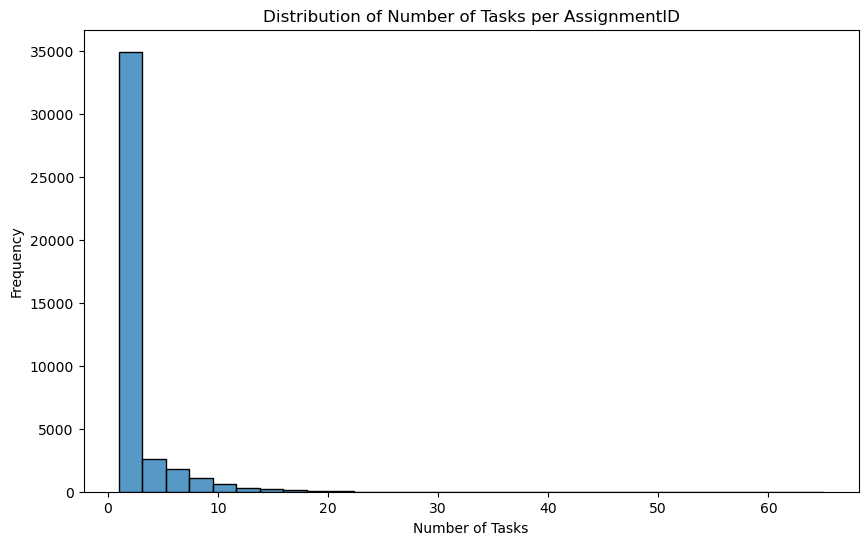

In [5]:
# Plot distribution of number of tasks in each AssignmentID
plt.figure(figsize=(10, 6))
sns.histplot(OE_detailed['AssignmentID'].value_counts(), bins=30)
plt.title('Distribution of Number of Tasks per AssignmentID')
plt.xlabel('Number of Tasks')
plt.ylabel('Frequency')
plt.show()

In [7]:
# loa raw OE-activity data
path = "../data/database_backups_csv/OE/OE_Activity.csv"
column_name = ["ActivityCode","UserID","WorkCode","AssignmentID","ProductID","Quantity","Timestamp","LocationID"]
oe_raw = pd.read_csv(path, header=None, names=column_name)

In [9]:
# Count percentage of rows where "ActivityCode" == "AssignmentOpen"
percentage_assignment_open = (oe_raw['ActivityCode'] == 'AssignmentOpen').mean() * 100
print(f"Percentage of 'AssignmentOpen' rows: {percentage_assignment_open:.2f}%")

Percentage of 'AssignmentOpen' rows: 0.93%


/var/folders/hs/r4ck14j54v17d80mrc1wt5kw0000gn/T/ipykernel_58911/1889122729.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  assignment_open_percentage = user_date_group.apply(lambda x: (x['ActivityCode'] == 'AssignmentOpen').mean() * 100).reset_index(name='AssignmentOpenPercentage')


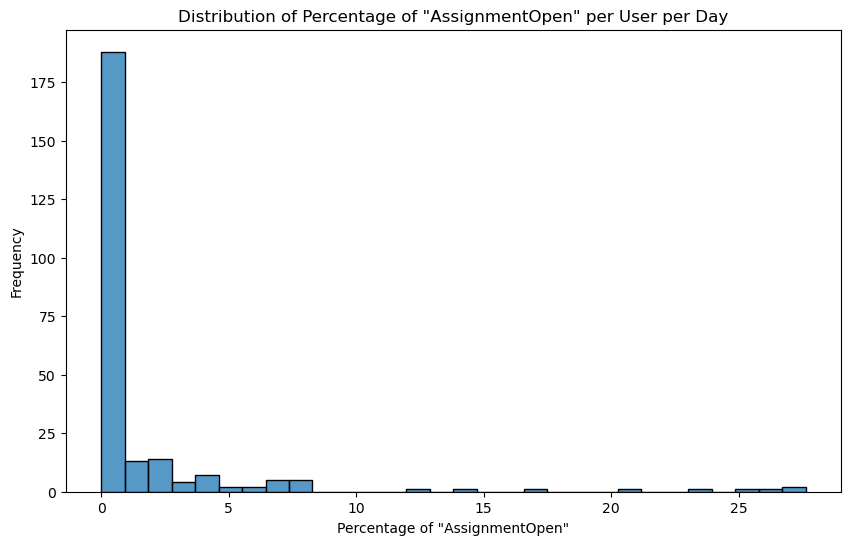

In [10]:
# For each user per day, compute the percentage of rows where "ActivityCode" == "AssignmentOpen", then plot the distribtion
oe_raw['Date'] = pd.to_datetime(oe_raw['Timestamp']).dt.date
user_date_group = oe_raw.groupby(['UserID', 'Date'])
assignment_open_percentage = user_date_group.apply(lambda x: (x['ActivityCode'] == 'AssignmentOpen').mean() * 100).reset_index(name='AssignmentOpenPercentage') 
plt.figure(figsize=(10, 6))
sns.histplot(assignment_open_percentage['AssignmentOpenPercentage'], bins=30)
plt.title('Distribution of Percentage of "AssignmentOpen" per User per Day')
plt.xlabel('Percentage of "AssignmentOpen"')
plt.ylabel('Frequency')
plt.show()

In [14]:
# Percentage of user-day combinations where no activities are "AssignmentOpen"
percentage_below_threshold = (assignment_open_percentage['AssignmentOpenPercentage'] == 0).mean() * 100
print(f"Percentage of user-day combinations with no 'AssignmentOpen' activities: {percentage_below_threshold:.2f}%")
# Percentage of user-day combinations where <0.25% of the activities are "AssignmentOpen"
percentage_below_threshold = (assignment_open_percentage['AssignmentOpenPercentage'] < 0.25).mean() * 100
print(f"Percentage of user-day combinations with less than 0.25% 'AssignmentOpen': {percentage_below_threshold:.2f}%")
# Percentage of user-day combinations where <0.5% of the activities are "AssignmentOpen"
percentage_below_threshold = (assignment_open_percentage['AssignmentOpenPercentage'] < 0.5).mean() * 100
print(f"Percentage of user-day combinations with less than 0.5% 'AssignmentOpen': {percentage_below_threshold:.2f}%")
# < 1%
percentage_below_1 = (assignment_open_percentage['AssignmentOpenPercentage'] < 1).mean() * 100
print(f"Percentage of user-day combinations with less than 1% 'AssignmentOpen': {percentage_below_1:.2f}%")

Percentage of user-day combinations with no 'AssignmentOpen' activities: 70.68%
Percentage of user-day combinations with less than 0.25% 'AssignmentOpen': 71.08%
Percentage of user-day combinations with less than 0.5% 'AssignmentOpen': 73.49%
Percentage of user-day combinations with less than 1% 'AssignmentOpen': 77.11%
